*Introduction to Deep Learning and Feedforward Neural Networks (FNNs)*

What is deep learning?

Deep learning is a subfield of machine learning that trains multi-layer neural networks to learn patterns from data. Unlike traditional methods that rely heavily on hand-crafted features, deep networks learn hierarchical features automatically — from low-level edges to high-level concepts — by composing many simple operations (linear transforms + nonlinearities).

# Lab Solution: Two FNNs on MNIST (NumPy & PyTorch)

This notebook contains **sample solutions** for the lab tasks:

1. **NumPy-only FNN** — two hidden layers **(30, 30)** implemented from scratch with vectorized NumPy (no autograd).
2. **PyTorch FNN** — two hidden layers **(256, 256)** implemented in PyTorch, with a **choice of optimizers** (SGD, Adam, RMSprop, AdamW).

Each section includes: data loading, model definition, training loop, evaluation, and explanatory comments. The notebook is arranged to be runnable end-to-end.

> Tip: If you run this in a CPU-only environment, reduce epochs or dataset size to keep runtimes small for the lab.


In [21]:
# Setup: imports, reproducibility, device
import time
import math
import numpy as np
import matplotlib.pyplot as plt

# PyTorch imports are optional — notebook will still work for NumPy section if torch is unavailable
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    import torch.optim as optim
    from torch.utils.data import DataLoader
    from torchvision import datasets, transforms
    TORCH_AVAILABLE = True
except Exception as e:
    TORCH_AVAILABLE = False
    print('PyTorch not available — PyTorch section will not run. Error:', e)

# Reproducible seeds
SEED = 42
np.random.seed(SEED)
if TORCH_AVAILABLE:
    torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if TORCH_AVAILABLE and torch.cuda.is_available() else 'cpu') if TORCH_AVAILABLE else None
print('Torch available:', TORCH_AVAILABLE, 'Device:', DEVICE)

# STEP 1
# import libraries, define how to reproduce(random seeds), device on which it runs.

Torch available: True Device: cpu


In [22]:
# example of iterator object in python, is used by DataLoader method
class MyNumbers:
  def __iter__(self):
    self.a = 1
    return self

  def __next__(self):
    x = self.a
    self.a += 1
    return x

myclass = MyNumbers()
myiter = iter(myclass)

print(next(myiter))
print(next(myiter))
print(next(myiter))
print(next(myiter))
print(next(myiter))

# when myclass is initialized it points to an object but that object is empty except for its methods.
# when we call iter method, here, both variables myclass and myiter point to same object but now that object has an atribute a=1. here myiter return same object
# An attribute, is a piece of data or a property that belongs to an object. 
# on calling next method, the a atribute changes the value inside the object and returns a value.

1
2
3
4
5


In [23]:
arr = np.zeros((3,2,2))
print(arr)
print(type(arr))
print(len(arr))

[[[0. 0.]
  [0. 0.]]

 [[0. 0.]
  [0. 0.]]

 [[0. 0.]
  [0. 0.]]]
<class 'numpy.ndarray'>
3


In [24]:
#STEP 2
# define constant for how to access dataset
USE_SMALL_SUBSET_FOR_NUMPY = True
NUMPY_TRAIN_SAMPLES = 5000
NUMPY_TEST_SAMPLES = 1000
BATCH_SIZE_NUMPY = 64
BATCH_SIZE_TORCH = 128
NUM_WORKERS = 2

# STEP 4
# understanding datasets and making code friendly.
if TORCH_AVAILABLE:
    transform = transforms.Compose([transforms.ToTensor()])
    train_dataset = datasets.MNIST(root='data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST(root='data', train=False, download=True, transform=transform)

    def dataset_to_numpy(ds, max_samples=None):
        """Load or convert data to a usable format.
Args:
    ds: input
    max_samples: input
Returns: value or object
"""
        n = len(ds) if max_samples is None else min(len(ds), max_samples)
        X = np.zeros((n, 28 * 28), dtype=np.float32)
        # the mnist dataset is 28*28 pixels.
        y = np.zeros((n,), dtype=np.int64)
        for i in range(n):
            img, label = ds[i]
            X[i] = np.array(img.view(-1))
            y[i] = int(label)
        return (X, y)
    X_all, y_all = dataset_to_numpy(train_dataset, max_samples=None)
    X_test_all, y_test_all = dataset_to_numpy(test_dataset, max_samples=None)
    if USE_SMALL_SUBSET_FOR_NUMPY:
        idx = np.random.permutation(X_all.shape[0])[:NUMPY_TRAIN_SAMPLES]
        X_numpy_train, y_numpy_train = (X_all[idx], y_all[idx])
        idx_test = np.random.permutation(X_test_all.shape[0])[:NUMPY_TEST_SAMPLES]
        X_numpy_test, y_numpy_test = (X_test_all[idx_test], y_test_all[idx_test])
    else:
        X_numpy_train, y_numpy_train = (X_all, y_all)
        X_numpy_test, y_numpy_test = (X_test_all, y_test_all)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_TORCH, shuffle=True, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE_TORCH, shuffle=False, num_workers=NUM_WORKERS)
else:
    print('Torch not available — please provide NumPy arrays X_numpy_train, y_numpy_train, X_numpy_test, y_numpy_test')
print('NumPy train shape:', X_numpy_train.shape, 'NumPy test shape:', X_numpy_test.shape)

C:\Users\Sachit Vij\AppData\Local\Temp\ipykernel_23824\3544443760.py:30: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X[i] = np.array(img.view(-1))


NumPy train shape: (5000, 784) NumPy test shape: (1000, 784)


In [25]:
print(train_dataset,'\n')
print(type(train_dataset),'\n')
print(len(train_dataset),'\n')

image, label = train_dataset[5]
print(image.shape, label)

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
           ) 

<class 'torchvision.datasets.mnist.MNIST'> 

60000 

torch.Size([1, 28, 28]) 2


In [26]:
img, label = train_dataset[0]
print(img,'\n')
print(img)

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [27]:
tensor = torch.zeros((1, 2, 2))
print(tensor)


tensor([[[0., 0.],
         [0., 0.]]])


In [28]:
np.array(img.view(-1))
# converting it to (28*28,) 1D array

C:\Users\Sachit Vij\AppData\Local\Temp\ipykernel_23824\2139237744.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.array(img.view(-1))


array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [29]:
def batch_iter(X, y, batch_size=64, shuffle=True):
    """Yield or produce data in small groups (batches).
Args:
ooh yaah bitch...
    X: input
    y: input
    batch_size: input
    shuffle: input
Returns: None
"""
    N = X.shape[0]
    idx = np.arange(N)
    if shuffle:
        np.random.shuffle(idx)
    for i in range(0, N, batch_size):
        batch_idx = idx[i: i+batch_size]
        yield (X[batch_idx], y[batch_idx])

def to_one_hot(y, num_classes):
    """Convert integer labels to one-hot vectors.
Args:sx
    y: input
    num_classes: input
Returns: value or object
"""
    return np.eye(num_classes)[y]

def relu(Z):
    """Compute activation or loss-related operation.
Args:
    Z: input
Returns: value or object
"""
    return np.maximum(0, Z)

def relu_grad(Z):
    """Compute activation or loss-related operation.
Args:
    Z: input
Returns: value or object
"""
    return (Z > 0).astype(np.float32)

def softmax(logits):
    """Compute activation or loss-related operation.
Args:
    logits: input
Returns: value or object
"""
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exps = np.exp(logits)
    return exps / np.sum(exps, axis=1, keepdims=True)

def softmax_cross_entropy_loss_and_grad(logits, y):
    """Compute activation or loss-related operation.
Args:
    logits: input
    y: input
Returns: value or object
"""
    N = logits.shape[0]
    probs = softmax(logits)
    clipped = np.clip(probs, 1e-12, 1.0)
    loss = -np.mean(np.log(clipped[np.arange(N), y]))
    grad = probs
    grad[np.arange(N), y] -= 1
    grad /= N
    return (loss, grad)
print('Helpers ready')

Helpers ready


In [30]:
class NumpyFNN:

    def __init__(self, input_dim, hidden_dims=(30, 30), num_classes=10, learning_rate=0.1):
        """Initialize an object or model.
Args:
    self: input
    input_dim: input
    hidden_dims: input
    num_classes: input
    learning_rate: input
Returns: None
"""
        self.lr = learning_rate
        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.num_classes = num_classes
        dims = [input_dim] + list(hidden_dims) + [num_classes]
        self.params = {}
        rng = np.random.RandomState(SEED)
        for i in range(len(dims) - 1):
            self.params[f'W{i}'] = rng.randn(dims[i], dims[i + 1]).astype(np.float32) * np.sqrt(2.0 / dims[i])
            self.params[f'b{i}'] = np.zeros((dims[i + 1],), dtype=np.float32)

    def forward(self, X):
        """Run data forward through the model to get outputs.
Args:
    self: input
    X: input
Returns: value or object
"""
        caches = {}
        A = X
        caches['A0'] = A
        Z1 = A @ self.params['W0'] + self.params['b0']
        A1 = relu(Z1)
        caches['Z1'], caches['A1'] = (Z1, A1)
        Z2 = A1 @ self.params['W1'] + self.params['b1']
        A2 = relu(Z2)
        caches['Z2'], caches['A2'] = (Z2, A2)
        Z3 = A2 @ self.params['W2'] + self.params['b2']
        caches['Z3'] = Z3
        return (Z3, caches)

    def update_params(self, grads):
        """Update model parameters (optimizer step).
Args:
    self: input
    grads: input
Returns: None
"""
        self.params['W0'] -= self.lr * grads['dW0']
        self.params['b0'] -= self.lr * grads['db0']
        self.params['W1'] -= self.lr * grads['dW1']
        self.params['b1'] -= self.lr * grads['db1']
        self.params['W2'] -= self.lr * grads['dW2']
        self.params['b2'] -= self.lr * grads['db2']

    def train_on_batch(self, Xb, yb):
        """Yield or produce data in small groups (batches).
Args:
    self: input
    Xb: input
    yb: input
Returns: value or object
"""
        logits, caches = self.forward(Xb)
        loss, dlogits = softmax_cross_entropy_loss_and_grad(logits, yb)
        dA2 = dlogits @ self.params['W2'].T
        dW2 = caches['A2'].T @ dlogits
        db2 = dlogits.sum(axis=0)
        dZ2 = dA2 * relu_grad(caches['Z2'])
        dA1 = dZ2 @ self.params['W1'].T
        dW1 = caches['A1'].T @ dZ2
        db1 = dZ2.sum(axis=0)
        dZ1 = dA1 * relu_grad(caches['Z1'])
        dW0 = caches['A0'].T @ dZ1
        db0 = dZ1.sum(axis=0)
        grads = {'dW2': dW2, 'db2': db2, 'dW1': dW1, 'db1': db1, 'dW0': dW0, 'db0': db0}
        self.update_params(grads)
        preds = np.argmax(logits, axis=1)
        acc = (preds == yb).mean()
        return (loss, acc)

    def predict(self, X):
        """Run data forward through the model to get outputs.
Args:
    self: input
    X: input
Returns: value or object
"""
        logits, _ = self.forward(X)
        return np.argmax(logits, axis=1)
print('NumPy FNN class defined')

NumPy FNN class defined


Epoch 1/15 — train loss 1.1809, train acc 0.638 — test loss 0.7412, test acc 0.753 (t=0.1s)
Epoch 2/15 — train loss 0.4710, train acc 0.853 — test loss 0.5341, test acc 0.827 (t=0.0s)
Epoch 3/15 — train loss 0.3498, train acc 0.895 — test loss 0.3581, test acc 0.880 (t=0.1s)
Epoch 4/15 — train loss 0.2943, train acc 0.913 — test loss 0.3691, test acc 0.876 (t=0.1s)
Epoch 5/15 — train loss 0.2671, train acc 0.919 — test loss 1.1979, test acc 0.697 (t=0.1s)
Epoch 6/15 — train loss 0.2409, train acc 0.926 — test loss 0.2565, test acc 0.917 (t=0.0s)
Epoch 7/15 — train loss 0.2021, train acc 0.937 — test loss 0.4649, test acc 0.852 (t=0.0s)
Epoch 8/15 — train loss 0.1823, train acc 0.947 — test loss 0.2718, test acc 0.910 (t=0.1s)
Epoch 9/15 — train loss 0.1634, train acc 0.950 — test loss 0.2366, test acc 0.925 (t=0.0s)
Epoch 10/15 — train loss 0.1458, train acc 0.955 — test loss 0.2365, test acc 0.924 (t=0.1s)
Epoch 11/15 — train loss 0.1276, train acc 0.964 — test loss 0.2858, test acc 0

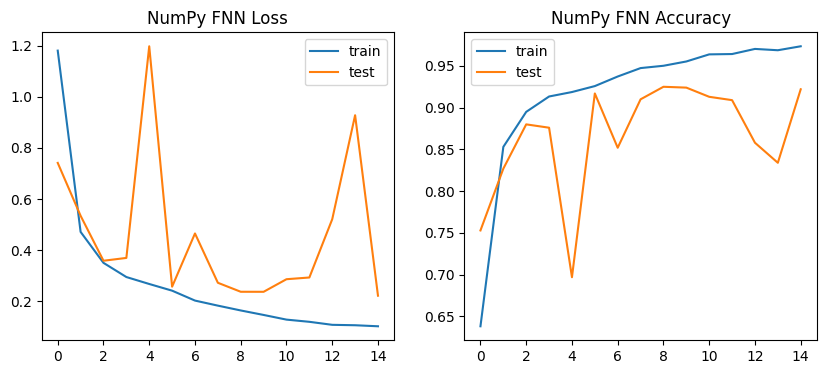

Final NumPy test accuracy: 0.922


In [31]:
# Train the NumPy FNN on the prepared NumPy subset
input_dim = X_numpy_train.shape[1]
np_model = NumpyFNN(input_dim=input_dim, hidden_dims=(30,30), num_classes=10, learning_rate=0.1)

EPOCHS_NUMPY = 15
history_numpy = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(1, EPOCHS_NUMPY+1):
    t0 = time.time()
    train_losses, train_accs = [], []
    for Xb, yb in batch_iter(X_numpy_train, y_numpy_train, batch_size=BATCH_SIZE_NUMPY, shuffle=True):
        loss, acc = np_model.train_on_batch(Xb, yb)
        train_losses.append(loss)
        train_accs.append(acc)
    # evaluate on small test set
    logits_test, _ = np_model.forward(X_numpy_test)
    test_loss, _ = softmax_cross_entropy_loss_and_grad(logits_test, y_numpy_test)
    preds_test = np.argmax(logits_test, axis=1)
    test_acc = (preds_test == y_numpy_test).mean()
    history_numpy['train_loss'].append(np.mean(train_losses))
    history_numpy['train_acc'].append(np.mean(train_accs))
    history_numpy['test_loss'].append(test_loss)
    history_numpy['test_acc'].append(test_acc)
    print(f"Epoch {epoch}/{EPOCHS_NUMPY} — train loss {history_numpy['train_loss'][-1]:.4f}, train acc {history_numpy['train_acc'][-1]:.3f} — test loss {test_loss:.4f}, test acc {test_acc:.3f} (t={time.time()-t0:.1f}s)")

# Plot training curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history_numpy['train_loss'], label='train')
plt.plot(history_numpy['test_loss'], label='test')
plt.title('NumPy FNN Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_numpy['train_acc'], label='train')
plt.plot(history_numpy['test_acc'], label='test')
plt.title('NumPy FNN Accuracy')
plt.legend()
plt.show()

# Final test accuracy
preds = np_model.predict(X_numpy_test)
print('Final NumPy test accuracy:', (preds == y_numpy_test).mean())

In [32]:
if TORCH_AVAILABLE:

    class TorchFNN(nn.Module):

        def __init__(self, input_dim=28 * 28, hidden_dim=256, num_classes=10):
            """Initialize an object or model.
Args:
    self: input
    input_dim: input
    hidden_dim: input
    num_classes: input
Returns: None
"""
            super().__init__()
            self.fc1 = nn.Linear(input_dim, hidden_dim)
            self.fc2 = nn.Linear(hidden_dim, hidden_dim)
            self.fc3 = nn.Linear(hidden_dim, num_classes)

        def forward(self, x):
            """Run data forward through the model to get outputs.
Args:
    self: input
    x: input
Returns: value or object
"""
            if x.dim() == 4:
                x = x.view(x.size(0), -1)
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            x = self.fc3(x)
            return x

    def make_optimizer(model, optim_name='sgd', lr=0.01, weight_decay=0.0):
        """Update model parameters (optimizer step).
Args:
    model: input
    optim_name: input
    lr: input
    weight_decay: input
Returns: value or object
"""
        optim_name = optim_name.lower()
        if optim_name == 'sgd':
            return optim.SGD(model.parameters(), lr=lr)
        elif optim_name == 'adam':
            return optim.Adam(model.parameters(), lr=lr)
        elif optim_name == 'rmsprop':
            return optim.RMSprop(model.parameters(), lr=lr)
        elif optim_name == 'adamw':
            return optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        else:
            raise ValueError(f'Unknown optimizer: {optim_name}')
    print('PyTorch model and optimizer factory ready')
else:
    print('Skipping PyTorch model definition because torch is not available')

PyTorch model and optimizer factory ready


In [33]:
if TORCH_AVAILABLE:

    def train_torch(model, train_loader, optimizer, device, epochs=5):
        """Train model parameters on given data.
Args:
    model: input
    train_loader: input
    optimizer: input
    device: input
    epochs: input
Returns: value or object
"""
        criterion = nn.CrossEntropyLoss()
        model.to(device)
        history = {'train_loss': [], 'train_acc': []}
        for epoch in range(1, epochs + 1):
            model.train()
            running_loss = 0.0
            correct = 0
            total = 0
            for imgs, labels in train_loader:
                imgs = imgs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * imgs.size(0)
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += imgs.size(0)
            train_loss = running_loss / total
            train_acc = correct / total
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            print(f'Epoch {epoch}/{epochs} — train loss {train_loss:.4f}, train acc {train_acc:.3f}')
        return history

    def evaluate_torch(model, data_loader, device):
        """Evaluate model performance on data.
Args:
    model: input
    data_loader: input
    device: input
Returns: value or object
"""
        model.eval()
        criterion = nn.CrossEntropyLoss(reduction='sum')
        running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for imgs, labels in data_loader:
                imgs = imgs.to(device)
                labels = labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                running_loss += loss.item()
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        return (running_loss / total, correct / total)
else:

    def train_torch(*args, **kwargs):
        """Train model parameters on given data.
Args:
    *args: input
    **kwargs: input
Returns: None
"""
        raise RuntimeError('Torch not available')

    def evaluate_torch(*args, **kwargs):
        """Evaluate model performance on data.
Args:
    *args: input
    **kwargs: input
Returns: None
"""
        raise RuntimeError('Torch not available')

Training PyTorch model with optimizer: adam
Epoch 1/5 — train loss 0.3258, train acc 0.907
Epoch 2/5 — train loss 0.1198, train acc 0.964
Epoch 3/5 — train loss 0.0765, train acc 0.977
Epoch 4/5 — train loss 0.0554, train acc 0.983
Epoch 5/5 — train loss 0.0411, train acc 0.986
Training done in 38.56828713417053 seconds
PyTorch test loss: 0.06989607717052568 test acc: 0.978


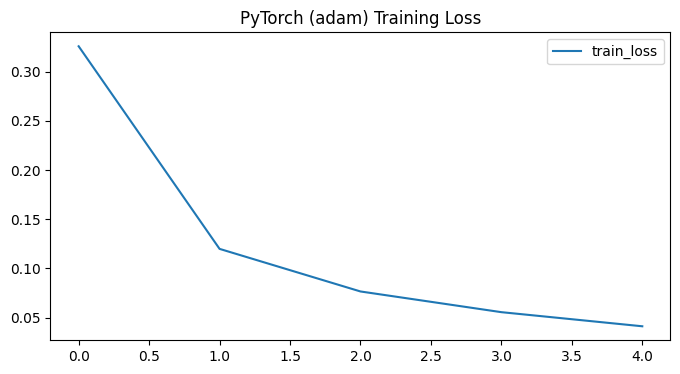

In [34]:
# Run PyTorch experiments — try different optimizers
if TORCH_AVAILABLE:
    optim_choice = 'adam'  # change to 'sgd', 'rmsprop', 'adamw' as desired
    model = TorchFNN(input_dim=28*28, hidden_dim=256, num_classes=10)
    optimizer = make_optimizer(model, optim_choice, lr=1e-3)
    print('Training PyTorch model with optimizer:', optim_choice)
    t0 = time.time()
    history_torch = train_torch(model, train_loader, optimizer, DEVICE, epochs=5)
    print('Training done in', time.time()-t0, 'seconds')
    test_loss, test_acc = evaluate_torch(model, test_loader, DEVICE)
    print('PyTorch test loss:', test_loss, 'test acc:', test_acc)

    # Plot training curves (if any)
    plt.figure(figsize=(8,4))
    plt.plot(history_torch['train_loss'], label='train_loss')
    plt.title(f'PyTorch ({optim_choice}) Training Loss')
    plt.legend()
    plt.show()
else:
    print('PyTorch section skipped')

# Summary & Teaching Notes

- The **NumPy FNN** implements forward and backward passes manually. It's excellent for teaching how gradients flow, and for debugging shape/initialization issues.
- The **PyTorch FNN** uses built-in layers, autograd, and optimizer implementations — great for scaling up and experimentation.

**Possible exercises:**
- Add L2 weight decay or dropout to both implementations.
- Implement Adam manually in the NumPy model and compare with PyTorch's Adam.
- Perform gradient checking on the NumPy model (finite differences) to ensure correctness.
